In [1]:
import os
from pathlib import Path
import pandas as pd
import numpy as np



## Align Neural, Behavioral, SLEAP Frames

In [2]:
def resolve_path(p) -> Path:
    clean = str(p).strip().strip('"').replace("\\", "/").lstrip("/")
    return lab_drive / clean

def load_sessions(sheet_path: str | Path, date_col: str = "date") -> pd.DataFrame:
    df = pd.read_csv(sheet_path)

    sessions = pd.DataFrame({
        "session_id": df[date_col].astype(str),
        "beh_csv": [resolve_path(p) for p in df["beh_csv_path"]],
        "sleap_csv": [resolve_path(p) for p in df["sleap_csv_path"]],
        "beh_vid": [resolve_path(p) for p in df["beh_vid_path"]],
    })

    # Neural is optional
    if "neu_csv_path" in df.columns:
        sessions["neu_csv"] = [
            resolve_path(p) if pd.notna(p) else None
            for p in df["neu_csv_path"]
        ]
    else:
        sessions["neu_csv"] = None

    # Check required files only
    required = sessions[["beh_csv", "sleap_csv", "beh_vid"]].to_numpy().ravel()
    missing = [p for p in required if not Path(p).exists()]
    if missing:
        raise FileNotFoundError(f"{len(missing)} files not found (showing first 5): {missing[:5]}")

    # Neural files only checked if present
    if sessions["neu_csv"].notna().any():
        missing_neu = [p for p in sessions["neu_csv"] if p is not None and not Path(p).exists()]
        if missing_neu:
            raise FileNotFoundError(f"Missing neural files (showing first 5): {missing_neu[:5]}")

    return sessions

In [3]:
def build_timeline(neu_df: pd.DataFrame,
    beh_df: pd.DataFrame, 
    fps: float, 
    ts_col: str = "Timestamp") -> pd.DataFrame:

    dt = pd.to_timedelta(1.0 / fps, unit="s")

    neu_ts = pd.to_datetime(neu_df[ts_col], utc=True, errors="coerce")
    beh_ts = pd.to_datetime(beh_df[ts_col], utc=True, errors="coerce")

    if neu_ts.isna().all() or beh_ts.isna().all():
        raise ValueError("All timestamps are NaT in neu or beh after parsing")

    t0 = min(neu_ts.min(), beh_ts.min())
    t1 = max(neu_ts.max(), beh_ts.max())

    global_ts = pd.date_range(start=t0, end=t1, freq=dt)

    return pd.DataFrame(
        {"global_idx": np.arange(len(global_ts), dtype=int), "global_ts": global_ts}
    )

def map_stream(stream_df: pd.DataFrame, 
    union_df: pd.DataFrame, 
    fps: float, 
    ts_col: str, 
    prefix: str, 
    add_frame_idx: bool = False,) -> pd.DataFrame:
    
    tol = pd.Timedelta(seconds=0.5 / fps)

    s = stream_df.copy()
    s[ts_col] = pd.to_datetime(s[ts_col], utc=True, errors="coerce")
    s = s.dropna(subset=[ts_col]).sort_values(ts_col).reset_index(drop=True)

    s["recorded_idx"] = np.arange(len(s), dtype=int)
    if add_frame_idx:
        s["beh_frame_idx"] = s["recorded_idx"]

    mapped = pd.merge_asof(
        union_df.sort_values("global_ts"),
        s.sort_values(ts_col),
        left_on="global_ts",
        right_on=ts_col,
        direction="nearest",
        tolerance=tol,
    )

    mapped[f"{prefix}_dropped"] = mapped["recorded_idx"].isna()
    mapped = mapped.rename(columns={ts_col: f"{prefix}_ts"})

    return mapped

def align_session(
    beh_path: Path,
    sleap_path: Path,
    fps: float,
    ts_col: str = "Timestamp",
    neu_path: Path | None = None,
    sleap_cols: list[str] | None = None,
) -> pd.DataFrame:

    beh_df = pd.read_csv(beh_path)
    sleap_df = pd.read_csv(sleap_path)

    if neu_path is not None:
        neu_df = pd.read_csv(neu_path)
        timeline = build_timeline(neu_df, beh_df, fps=fps, ts_col=ts_col)
    else:
        # build timeline from behavior only
        beh_ts = pd.to_datetime(beh_df[ts_col], utc=True, errors="coerce")
        dt = pd.to_timedelta(1.0 / fps, unit="s")
        global_ts = pd.date_range(start=beh_ts.min(), end=beh_ts.max(), freq=dt)
        timeline = pd.DataFrame({
            "global_idx": np.arange(len(global_ts), dtype=int),
            "global_ts": global_ts
        })

    beh_stream = map_stream(
        beh_df, timeline, fps=fps, ts_col=ts_col,
        prefix="beh", add_frame_idx=True
    )

    if neu_path is not None:
        neu_stream = map_stream(
            neu_df, timeline, fps=fps, ts_col=ts_col,
            prefix="neu", add_frame_idx=False
        )
        aligned = beh_stream.merge(
            neu_stream.drop(columns=["global_ts"]),
            on="global_idx",
            how="left"
        )
    else:
        aligned = beh_stream.copy()
        aligned["neu_ts"] = pd.NaT
        aligned["neu_dropped"] = True

    # --- SLEAP merge ---
    sleap = sleap_df.copy().rename(columns={"frame_idx": "beh_frame_idx"})
    sleap["beh_frame_idx"] = pd.to_numeric(sleap["beh_frame_idx"], errors="coerce")
    aligned["beh_frame_idx"] = pd.to_numeric(aligned["beh_frame_idx"], errors="coerce")

    if sleap_cols is None:
        sleap_cols = ["nose.x", "nose.y", "ear_L.x", "ear_L.y", "ear_R.x", "ear_R.y"]

    keep = ["beh_frame_idx"] + [c for c in sleap_cols if c in sleap.columns]
    aligned = aligned.merge(sleap[keep], on="beh_frame_idx", how="left")

    return aligned

def align_all(sheet_path, fps, ts_col="Timestamp", date_col="date"):

    sessions = load_sessions(sheet_path, date_col=date_col)
    aligned_by_session = {}

    for _, row in sessions.iterrows():
        session_id = row["session_id"]

        aligned = align_session(
            beh_path=row["beh_csv"],
            sleap_path=row["sleap_csv"],
            neu_path=row["neu_csv"],   # can be None
            fps=fps,
            ts_col=ts_col,
        )

        aligned["session_id"] = session_id
        aligned["beh_vid_path"] = str(row["beh_vid"])

        aligned_by_session[session_id] = aligned

    return aligned_by_session, sessions


In [4]:
sheet_path = "/Users/may/Projects/1p_pipeline/20260228_paths.csv"
lab_drive = Path(os.environ.get("LAB_DRIVE_PATH", "/Volumes/ASA_Lab")) # replace with your actual lab drive path
fps = 30

In [5]:



aligned_sessions, sessions = align_all(sheet_path=sheet_path, fps=fps, ts_col="Timestamp")


In [6]:
sessions

,session_id,beh_csv,sleap_csv,beh_vid,neu_csv
0,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
1,11/13/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
2,11/14/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
3,11/18/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
4,11/20/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
5,11/21/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,None
6,11/25/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Users/May/SLEAP/Miniscope_Mod...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...


In [7]:
aligned_sessions["11/6/25"]

,global_idx,global_ts,Value,beh_ts,recorded_idx_x,beh_frame_idx,beh_dropped,Value.ElementType,Value.Size.Width,Value.Size.Height,...,recorded_idx_y,neu_dropped,nose.x,nose.y,ear_L.x,ear_L.y,ear_R.x,ear_R.y,session_id,beh_vid_path
0,0,2025-11-06 22:08:41.619187200+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,0.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
1,1,2025-11-06 22:08:41.652520533+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,1.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
2,2,2025-11-06 22:08:41.685853866+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,2.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
3,3,2025-11-06 22:08:41.719187199+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,3.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
4,4,2025-11-06 22:08:41.752520532+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,4.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74706,74706,2025-11-06 22:50:11.819162298+00:00,74686.0,2025-11-06 22:50:11.805721600+00:00,74686.0,74686.0,False,0.0,608.0,608.0,...,75189.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
74707,74707,2025-11-06 22:50:11.852495631+00:00,74687.0,2025-11-06 22:50:11.839321600+00:00,74687.0,74687.0,False,0.0,608.0,608.0,...,75190.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
74708,74708,2025-11-06 22:50:11.885828964+00:00,74688.0,2025-11-06 22:50:11.872332800+00:00,74688.0,74688.0,False,0.0,608.0,608.0,...,75191.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...
74709,74709,2025-11-06 22:50:11.919162297+00:00,74689.0,2025-11-06 22:50:11.906124800+00:00,74689.0,74689.0,False,0.0,608.0,608.0,...,75192.0,False,NaN,NaN,NaN,NaN,NaN,NaN,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...


In [8]:
len(aligned_sessions)

7

## Calculate Pose Variables

In [9]:
import numpy as np
import pandas as pd

def compute_position_from_df(
    df: pd.DataFrame,
    ts_col: str = "global_ts",
    use_dt_from_timestamps: bool = True,
    fps: float = 30.0,
    assume_sorted: bool = False,
) -> pd.DataFrame:

    df = df.copy()

    required = ["ear_L.x", "ear_L.y", "ear_R.x", "ear_R.y", "nose.x", "nose.y"]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"DataFrame missing required columns: {missing}")

    # --- timestamps ---
    if use_dt_from_timestamps:
        df[ts_col] = pd.to_datetime(df[ts_col], utc=True, errors="coerce")

        if not assume_sorted:
            df = df.sort_values(ts_col).reset_index(drop=True)

        dt = df[ts_col].diff().dt.total_seconds().to_numpy()
    else:
        if not assume_sorted:
            df = df.reset_index(drop=True)
        dt = np.full(len(df), 1.0 / float(fps), dtype=float)
        dt[0] = np.nan

    # --- ear midpoint ---
    df["ear_mid_x"] = (df["ear_L.x"] + df["ear_R.x"]) / 2.0
    df["ear_mid_y"] = (df["ear_L.y"] + df["ear_R.y"]) / 2.0

    # --- head direction ---
    df["hd_dx"] = df["nose.x"] - df["ear_mid_x"]
    df["hd_dy"] = df["nose.y"] - df["ear_mid_y"]
    df["head_dir_rad"] = np.arctan2(df["hd_dy"], df["hd_dx"])

    # --- angular velocity ---
    ang = df["head_dir_rad"].to_numpy(dtype=float)
    ang_unwrapped = np.full_like(ang, np.nan)

    valid = np.isfinite(ang)
    if valid.any():
        ang_unwrapped[valid] = np.unwrap(ang[valid])

    dtheta = np.diff(ang_unwrapped)
    ang_vel = np.full(len(df), np.nan)

    dt_step = dt[1:]
    good_steps = np.isfinite(dtheta) & np.isfinite(dt_step) & (dt_step > 0)

    ang_vel[1:][good_steps] = dtheta[good_steps] / dt_step[good_steps]

    df["ang_vel_rad_s"] = ang_vel
    df["ang_vel_deg_s"] = np.degrees(ang_vel)
    df["ang_vel_speed"] = np.abs(ang_vel)

    return df

In [10]:
def compute_position_for_sessions(
    session_dict: dict[str, pd.DataFrame],
    **kwargs
) -> dict[str, pd.DataFrame]:

    out = {}

    for session_id, df in session_dict.items():
        print(f"Processing session: {session_id}")
        out[session_id] = compute_position_from_df(df, **kwargs)

    return out

In [11]:
aligned_sessions = compute_position_for_sessions(aligned_sessions, ts_col="global_ts", fps=fps)

Processing session: 11/6/25
Processing session: 11/13/25
Processing session: 11/14/25
Processing session: 11/18/25
Processing session: 11/20/25
Processing session: 11/21/25
Processing session: 11/25/25


In [12]:
aligned_sessions["11/6/25"]

,global_idx,global_ts,Value,beh_ts,recorded_idx_x,beh_frame_idx,beh_dropped,Value.ElementType,Value.Size.Width,Value.Size.Height,...,session_id,beh_vid_path,ear_mid_x,ear_mid_y,hd_dx,hd_dy,head_dir_rad,ang_vel_rad_s,ang_vel_deg_s,ang_vel_speed
0,0,2025-11-06 22:08:41.619187200+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,2025-11-06 22:08:41.652520533+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,2025-11-06 22:08:41.685853866+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,2025-11-06 22:08:41.719187199+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,2025-11-06 22:08:41.752520532+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74706,74706,2025-11-06 22:50:11.819162298+00:00,74686.0,2025-11-06 22:50:11.805721600+00:00,74686.0,74686.0,False,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74707,74707,2025-11-06 22:50:11.852495631+00:00,74687.0,2025-11-06 22:50:11.839321600+00:00,74687.0,74687.0,False,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74708,74708,2025-11-06 22:50:11.885828964+00:00,74688.0,2025-11-06 22:50:11.872332800+00:00,74688.0,74688.0,False,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
74709,74709,2025-11-06 22:50:11.919162297+00:00,74689.0,2025-11-06 22:50:11.906124800+00:00,74689.0,74689.0,False,0.0,608.0,608.0,...,11/6/25,/Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Select Arena ROIs

In [13]:
import json
import time
import cv2
import numpy as np
from pathlib import Path

def collect_roi_opencv(video_path, roi_json_path, title="ROI (L-add, R-undo, s-save, q-quit)"):
    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise ValueError(f"Could not read frame from video: {video_path}")

    points = []

    def redraw(img, pts):
        out = img.copy()
        for (x, y) in pts:
            cv2.circle(out, (x, y), 4, (255, 0, 0), -1)
        if len(pts) >= 2:
            p = np.array(pts, np.int32).reshape((-1, 1, 2))
            cv2.polylines(out, [p], False, (0, 255, 0), 2)
        cv2.putText(out, f"Points: {len(pts)}", (10, 30),
                    cv2.FONT_HERSHEY_SIMPLEX, 1.0, (255, 255, 255), 2)
        return out

    display = redraw(frame, points)

    def on_mouse(event, x, y, flags, param):
        nonlocal points, display
        if event == cv2.EVENT_LBUTTONDOWN:
            points.append((int(x), int(y)))
            display = redraw(frame, points)
        elif event == cv2.EVENT_RBUTTONDOWN:
            if points:
                points.pop()
                display = redraw(frame, points)

    cv2.namedWindow(title, cv2.WINDOW_NORMAL)
    cv2.setMouseCallback(title, on_mouse)

    while True:
        cv2.imshow(title, display)

        # Detect if user closed the window manually
        if cv2.getWindowProperty(title, cv2.WND_PROP_VISIBLE) < 1:
            cv2.destroyWindow(title)
            cv2.waitKey(1)
            raise RuntimeError("Window closed without saving ROI.")

        key = cv2.waitKey(20) & 0xFF

        if key == ord('s'):
            if len(points) < 3:
                print("Need at least 3 points to save a polygon.")
                continue
            roi_json_path = Path(roi_json_path)
            roi_json_path.parent.mkdir(parents=True, exist_ok=True)
            with open(roi_json_path, "w") as f:
                json.dump(points, f)
            print("Saved ROI:", str(roi_json_path))

            cv2.destroyWindow(title)
            cv2.waitKey(1)
            break

        if key == ord('q') or key == 27:
            cv2.destroyWindow(title)
            cv2.waitKey(1)
            raise RuntimeError("Quit without saving ROI.")

        time.sleep(0.001)

    return frame, points

In [14]:
from pathlib import Path

PROJECT_ROOT = Path.cwd()           # notebook folder
ROI_ROOT = PROJECT_ROOT / "20260228_2-5-A_20251106-1125_rois"
ROI_ROOT.mkdir(exist_ok=True)

In [15]:
def roi_json_for_video(video_path, roi_name, session_id):
    return ROI_ROOT / f"{session_id}__{roi_name}.json"

In [16]:
def load_or_collect_roi(video_path, roi_name, session_id, title=None):
    video_path = Path(video_path)
    roi_json_path = roi_json_for_video(video_path, roi_name, session_id)

    if roi_json_path.exists():
        with open(roi_json_path, "r") as f:
            points = json.load(f)
        print(f"Loaded existing ROI: {roi_json_path}")
        return points, roi_json_path

    if title is None:
        title = f"{roi_name} ROI (L-add, R-undo, s-save, q-quit)"

    _, points = collect_roi_opencv(video_path, roi_json_path, title=title)
    return points, roi_json_path

In [17]:
def collect_rois_for_sessions(
    sessions_df,
    video_col="beh_vid",
    roi_names=("arena", "startbox_L", "startbox_R"),
):

    rois = {}

    for _, row in sessions_df.iterrows():
        session_id = str(row["session_id"])
        video_path = row[video_col]

        print(f"\n=== {session_id} ===")
        print("video:", video_path)

        rois[session_id] = {}

        for roi_name in roi_names:
            pts, json_path = load_or_collect_roi(
                video_path=video_path,
                roi_name=roi_name,
                session_id=session_id,   # <-- add this
                title=f"{session_id} — {roi_name} ROI"
            )

            rois[session_id][roi_name] = {
                "points": pts,
                "json_path": json_path,
            }

    return rois

In [18]:
def load_or_collect_rois(video_path, roi_dir, roi_names):
    """
    roi_names e.g. ["arena", "startbox_L", "startbox_R", "goal"]
    Saves/loads each polygon as <roi_dir>/<name>.json
    Returns: rois dict {name: np.ndarray shape (N,2)}, plus frame0 size
    """
    video_path = Path(video_path)
    roi_dir = Path(roi_dir)
    roi_dir.mkdir(parents=True, exist_ok=True)

    # grab frame0 for shape
    cap = cv2.VideoCapture(str(video_path))
    ret, frame0 = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read first frame from: {video_path}")
    H, W = frame0.shape[:2]

    rois = {}
    for name in roi_names:
        roi_json = roi_dir / f"{name}.json"
        if roi_json.exists():
            with open(roi_json, "r") as f:
                pts = json.load(f)
            print(f"Loaded ROI {name}: {roi_json}")
        else:
            _, pts = collect_roi_opencv(video_path, roi_json, title=f"{name} ROI (L-add, R-undo, s-save, q-quit)")
        rois[name] = np.array(pts, dtype=np.float32)  # (N,2)

    return rois, (H, W)

In [19]:
rois_by_session = collect_rois_for_sessions(
    sessions,                 # your sheet-derived DF
    video_col="beh_vid",
    roi_names=["arena", "startbox_L", "startbox_R"]
)



=== 11/6/25 ===
video: /Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5-A/20251106/beh-cam_0.avi
Loaded existing ROI: /Users/may/Projects/1p_pipeline/20260228_2-5-A_20251106-1125_rois/11/6/25__arena.json
Loaded existing ROI: /Users/may/Projects/1p_pipeline/20260228_2-5-A_20251106-1125_rois/11/6/25__startbox_L.json
Loaded existing ROI: /Users/may/Projects/1p_pipeline/20260228_2-5-A_20251106-1125_rois/11/6/25__startbox_R.json

=== 11/13/25 ===
video: /Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5-A/20251113/beh-cam_3.avi
Loaded existing ROI: /Users/may/Projects/1p_pipeline/20260228_2-5-A_20251106-1125_rois/11/13/25__arena.json
Loaded existing ROI: /Users/may/Projects/1p_pipeline/20260228_2-5-A_20251106-1125_rois/11/13/25__startbox_L.json
Loaded existing ROI: /Users/may/Projects/1p_pipeline/20260228_2-5-A_20251106-1125_rois/11/13/25__startbox_R.json

=== 11/14/25 ===
video: /Volumes/ASA_Lab/Data/May/Cross_Maze/CCTT6-2-5-A/20251114/beh-cam_0.avi
Loaded existing ROI: /Users/may/Projects/1p_p

In [20]:
def signed_dist_to_poly(poly_xy, x, y):
    contour = poly_xy.astype(np.float32).reshape((-1, 1, 2))
    return float(cv2.pointPolygonTest(contour, (float(x), float(y)), measureDist=True))

def add_roi_features(df, rois, ref_x="ear_mid_x", ref_y="ear_mid_y"):
    out = df.copy()
    xs = out[ref_x].to_numpy()
    ys = out[ref_y].to_numpy()

    valid = np.isfinite(xs) & np.isfinite(ys)

    for name, poly in rois.items():
        inside = np.zeros(len(out), dtype=bool)
        sdist = np.full(len(out), np.nan, dtype=float)

        for i in np.where(valid)[0]:
            x, y = xs[i], ys[i]
            d = signed_dist_to_poly(poly, x, y)
            sdist[i] = d
            inside[i] = d >= 0  # inside if signed dist >= 0

        out[f"in_{name}"] = inside
        out[f"{name}_signed_dist_px"] = sdist
        out[f"{name}_dist_px"] = np.abs(sdist)

    return out



In [21]:
def polygon_to_mask(poly_xy, H, W):
    mask = np.zeros((H, W), dtype=np.uint8)
    pts = poly_xy.astype(np.int32).reshape((-1, 1, 2))
    cv2.fillPoly(mask, [pts], 255)
    return mask

def build_roi_masks(rois, H, W):
    return {name: polygon_to_mask(poly, H, W) for name, poly in rois.items()}

In [22]:
import json
import numpy as np
from pathlib import Path

def load_roi_polygons_for_session(rois_entry: dict) -> dict[str, np.ndarray]:
    """
    rois_entry is like: rois_by_session[session_id]
      { "arena": {"json_path": Path(...)}, "startbox_L": {...}, ... }

    Returns: { "arena": np.ndarray(N,2), ... }
    """
    polys = {}
    for name, meta in rois_entry.items():
        jp = Path(meta["json_path"]) if isinstance(meta, dict) else Path(meta)
        with open(jp, "r") as f:
            pts = json.load(f)
        polys[name] = np.asarray(pts, dtype=float)  # shape (N,2)
    return polys



In [23]:
import cv2

def get_video_hw(video_path: str | Path) -> tuple[int, int]:
    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read first frame from: {video_path}")
    H, W = frame.shape[:2]
    return H, W

In [24]:
import numpy as np
from pathlib import Path

def polygon_centroid(poly_xy: np.ndarray) -> tuple[float, float]:
    # simple centroid; good for convex ROIs / hand-drawn arena polygons
    c = np.asarray(poly_xy, dtype=float)
    return float(c[:, 0].mean()), float(c[:, 1].mean())

def polygon_max_radius(poly_xy: np.ndarray, cx: float, cy: float) -> float:
    c = np.asarray(poly_xy, dtype=float)
    r = np.sqrt((c[:, 0] - cx)**2 + (c[:, 1] - cy)**2)
    return float(np.nanmax(r))

In [25]:
def add_rois_to_all_sessions(
    aligned_sessions: dict[str, pd.DataFrame],
    rois_by_session: dict[str, dict],
    sessions_df: pd.DataFrame,
    session_id_col: str = "session_id",
    video_col: str = "beh_vid",
    ref_x: str = "ear_mid_x",
    ref_y: str = "ear_mid_y",
) -> tuple[dict[str, pd.DataFrame], dict[str, dict[str, np.ndarray]]]:

    sessions_lookup = sessions_df.set_index(session_id_col)

    aligned_with_rois = {}
    masks_by_session = {}

    for session_id, df in aligned_sessions.items():
        if session_id not in rois_by_session:
            print(f"Skipping {session_id}: no ROIs collected")
            aligned_with_rois[session_id] = df
            continue

        polys = load_roi_polygons_for_session(rois_by_session[session_id])

        # add boolean + signed distance features (your existing function)
        df2 = add_roi_features(df, polys, ref_x=ref_x, ref_y=ref_y)

        # ---- NEW: arena center distance ----
        if "arena" in polys:
            cx, cy = polygon_centroid(polys["arena"])
            df2["arena_center_x"] = cx
            df2["arena_center_y"] = cy

            x = df2[ref_x].to_numpy(dtype=float, copy=False)
            y = df2[ref_y].to_numpy(dtype=float, copy=False)
            df2["dist_to_arena_center_px"] = np.sqrt((x - cx)**2 + (y - cy)**2)

            # optional: normalize by arena "radius" (max vertex distance from centroid)
            rmax = polygon_max_radius(polys["arena"], cx, cy)
            df2["dist_to_arena_center_norm"] = df2["dist_to_arena_center_px"] / rmax if rmax > 0 else np.nan
        else:
            df2["arena_center_x"] = np.nan
            df2["arena_center_y"] = np.nan
            df2["dist_to_arena_center_px"] = np.nan
            df2["dist_to_arena_center_norm"] = np.nan
        # ---- /NEW ----

        # build masks (needs H,W from video)
        video_path = Path(sessions_lookup.loc[session_id, video_col])
        H, W = get_video_hw(video_path)
        masks = build_roi_masks(polys, H, W)

        aligned_with_rois[session_id] = df2
        masks_by_session[session_id] = masks

        print(f"{session_id}: added ROI features for {list(polys.keys())} (H,W=({H},{W}))")

    return aligned_with_rois, masks_by_session

In [26]:
aligned_sessions_with_rois, masks_by_session = add_rois_to_all_sessions(
    aligned_sessions=aligned_sessions,      # dict[session_id -> df]
    rois_by_session=rois_by_session,        # dict[session_id -> roi info]
    sessions_df=sessions,                   # metadata df with beh_vid
    session_id_col="session_id",
    video_col="beh_vid",
    ref_x="ear_mid_x",
    ref_y="ear_mid_y",
)

11/6/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
11/13/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
11/14/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
11/18/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
11/20/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
11/21/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))
11/25/25: added ROI features for ['arena', 'startbox_L', 'startbox_R'] (H,W=(2048,2048))


In [27]:
aligned_sessions_with_rois["11/6/25"]

,global_idx,global_ts,Value,beh_ts,recorded_idx_x,beh_frame_idx,beh_dropped,Value.ElementType,Value.Size.Width,Value.Size.Height,...,in_startbox_L,startbox_L_signed_dist_px,startbox_L_dist_px,in_startbox_R,startbox_R_signed_dist_px,startbox_R_dist_px,arena_center_x,arena_center_y,dist_to_arena_center_px,dist_to_arena_center_norm
0,0,2025-11-06 22:08:41.619187200+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
1,1,2025-11-06 22:08:41.652520533+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
2,2,2025-11-06 22:08:41.685853866+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
3,3,2025-11-06 22:08:41.719187199+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
4,4,2025-11-06 22:08:41.752520532+00:00,NaN,NaT,NaN,NaN,True,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
74706,74706,2025-11-06 22:50:11.819162298+00:00,74686.0,2025-11-06 22:50:11.805721600+00:00,74686.0,74686.0,False,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
74707,74707,2025-11-06 22:50:11.852495631+00:00,74687.0,2025-11-06 22:50:11.839321600+00:00,74687.0,74687.0,False,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
74708,74708,2025-11-06 22:50:11.885828964+00:00,74688.0,2025-11-06 22:50:11.872332800+00:00,74688.0,74688.0,False,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN
74709,74709,2025-11-06 22:50:11.919162297+00:00,74689.0,2025-11-06 22:50:11.906124800+00:00,74689.0,74689.0,False,0.0,608.0,608.0,...,False,NaN,NaN,False,NaN,NaN,895.8,1031.6,NaN,NaN


In [28]:
import numpy as np
import pandas as pd

def fill_short_gaps(mask: np.ndarray, gap_frames: int) -> np.ndarray:
    m = mask.astype(bool).copy()
    n = len(m)
    i = 0
    while i < n:
        if m[i]:
            i += 1
            continue
        j = i
        while j < n and not m[j]:
            j += 1
        left_true = (i - 1 >= 0 and m[i - 1])
        right_true = (j < n and m[j])
        if left_true and right_true and (j - i) <= gap_frames:
            m[i:j] = True
        i = j
    return m

def remove_short_runs(mask: np.ndarray, min_run_frames: int) -> np.ndarray:
    m = mask.astype(bool).copy()
    n = len(m)
    i = 0
    while i < n:
        if not m[i]:
            i += 1
            continue
        j = i
        while j < n and m[j]:
            j += 1
        if (j - i) < min_run_frames:
            m[i:j] = False
        i = j
    return m

def debounce(mask: np.ndarray, gap_frames=10, min_run_frames=3) -> np.ndarray:
    m = fill_short_gaps(mask, gap_frames=gap_frames)
    m = remove_short_runs(m, min_run_frames=min_run_frames)
    return m

In [29]:
import numpy as np

def segment_trials_gap_window(
    df,
    startbox_col="in_startbox_L",
    arena_only_col="arena_only",
    fps=30.0,
    max_gap_s=3.0,
    dwell_frames=1,      # start with 1; increase to 3–6 after it works
    min_trial_s=0.5,
):
    sb = df[startbox_col].astype(bool).to_numpy()
    ar = df[arena_only_col].astype(bool).to_numpy()
    gap = (~sb) & (~ar)

    max_gap = int(round(max_gap_s * fps))
    min_trial = int(round(min_trial_s * fps))

    def stable(mask, i):
        return mask[i:i+dwell_frames].sum() >= dwell_frames

    trials = []
    i = 0
    n = len(df)

    while i < n:
        # find a startbox moment
        while i < n and not stable(sb, i):
            i += 1
        if i >= n: break

        # leave startbox
        j = i
        while j < n and sb[j]:
            j += 1
        if j >= n: break

        # find arena entry within window after leaving startbox
        win_end = min(n, j + max_gap)
        k = j
        s = None
        while k < win_end:
            if stable(ar, k):
                s = k
                break
            k += 1
        if s is None:
            i = j
            continue

        # find startbox re-entry within window after being in arena at least once
        m = s + 1
        e = None
        while m < n:
            if stable(sb, m):
                # require we saw arena within the last max_gap frames
                lo = max(0, m - max_gap)
                if ar[lo:m].any():
                    e = m
                    break
            m += 1
        if e is None:
            break

        if (e - s) >= min_trial:
            trials.append((int(s), int(e)))

        i = e + 1

    return trials

In [30]:
trials_by_session = {}

for session_id, df in aligned_sessions_with_rois.items():
    df = df.copy()

    # define arena_only (edit logic as needed)
    df["arena_only"] = df["in_arena"] & (~df["in_startbox_L"])

    trials = segment_trials_gap_window(
        df,
        startbox_col="in_startbox_L",
        arena_only_col="arena_only",
        fps=30.0,
        max_gap_s=5.0,
        dwell_frames=1,
        min_trial_s=0.5,
    )

    trials_by_session[session_id] = trials
    print(f"{session_id}: {len(trials)} trials")

11/6/25: 126 trials
11/13/25: 90 trials
11/14/25: 75 trials
11/18/25: 82 trials
11/20/25: 87 trials
11/21/25: 114 trials
11/25/25: 45 trials


In [31]:
sb = aligned_sessions_with_rois["11/18/25"]["in_startbox_L"].astype(bool).to_numpy()
ar = aligned_sessions_with_rois["11/18/25"]["in_arena"].astype(bool).to_numpy()
gap = (~sb) & (~ar)

print("N:", len(aligned_sessions_with_rois["11/18/25"]))
print("startbox True:", sb.sum())
print("arena_only True:", ar.sum())
print("gap True:", gap.sum())

print("sb & arena_only overlap (should be 0):", (sb & ar).sum())

N: 55664
startbox True: 10458
arena_only True: 36851
gap True: 8355
sb & arena_only overlap (should be 0): 0


In [32]:
sb_prev = np.r_[False, sb[:-1]]
ar_prev = np.r_[False, ar[:-1]]
gap_prev = np.r_[False, gap[:-1]]

sb_to_gap = np.where(sb_prev & gap)[0]
gap_to_ar = np.where(gap_prev & ar)[0]
ar_to_gap = np.where(ar_prev & gap)[0]
gap_to_sb = np.where(gap_prev & sb)[0]

print("sb->gap:", len(sb_to_gap))
print("gap->arena:", len(gap_to_ar))
print("arena->gap:", len(ar_to_gap))
print("gap->sb:", len(gap_to_sb))

sb->gap: 146
gap->arena: 470
arena->gap: 470
gap->sb: 146


In [33]:
trials_by_session.keys()

dict_keys(['11/6/25', '11/13/25', '11/14/25', '11/18/25', '11/20/25', '11/21/25', '11/25/25'])

In [61]:
aligned_sessions_with_rois["11/18/25"]

,global_idx,global_ts,Value,beh_ts,recorded_idx,beh_frame_idx,beh_dropped,neu_ts,neu_dropped,nose.x,...,in_startbox_L,startbox_L_signed_dist_px,startbox_L_dist_px,in_startbox_R,startbox_R_signed_dist_px,startbox_R_dist_px,arena_center_x,arena_center_y,dist_to_arena_center_px,dist_to_arena_center_norm
0,0,2025-11-18 21:28:59.174028800+00:00,0.0,2025-11-18 21:28:59.174028800+00:00,0.0,0.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
1,1,2025-11-18 21:28:59.207362133+00:00,1.0,2025-11-18 21:28:59.205824+00:00,1.0,1.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
2,2,2025-11-18 21:28:59.240695466+00:00,2.0,2025-11-18 21:28:59.239552+00:00,2.0,2.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
3,3,2025-11-18 21:28:59.274028799+00:00,3.0,2025-11-18 21:28:59.272422400+00:00,3.0,3.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
4,4,2025-11-18 21:28:59.307362132+00:00,4.0,2025-11-18 21:28:59.306009600+00:00,4.0,4.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55659,55659,2025-11-18 21:59:54.474010247+00:00,55651.0,2025-11-18 21:59:54.470592+00:00,55651.0,55651.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55660,55660,2025-11-18 21:59:54.507343580+00:00,55652.0,2025-11-18 21:59:54.503616+00:00,55652.0,55652.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55661,55661,2025-11-18 21:59:54.540676913+00:00,55653.0,2025-11-18 21:59:54.537305600+00:00,55653.0,55653.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55662,55662,2025-11-18 21:59:54.574010246+00:00,55654.0,2025-11-18 21:59:54.570227200+00:00,55654.0,55654.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN


In [59]:
trials_by_session

{'11/6/25': [(1630, 1996),
  (2192, 2356),
  (2653, 2947),
  (3060, 3176),
  (3424, 3644),
  (3855, 4288),
  (4448, 4922),
  (5190, 5380),
  (5564, 5856),
  (6053, 6313),
  (6720, 7457),
  (7639, 7775),
  (7872, 8031),
  (8190, 8469),
  (8817, 9130),
  (9209, 9328),
  (9426, 9728),
  (9839, 10057),
  (10271, 10453),
  (10591, 10714),
  (11044, 11304),
  (11470, 11784),
  (12021, 12214),
  (12353, 12519),
  (12705, 13126),
  (13245, 13352),
  (13461, 13599),
  (13849, 14246),
  (14479, 14663),
  (14723, 15335),
  (15431, 15957),
  (16198, 16650),
  (16890, 16993),
  (17050, 17432),
  (17624, 17688),
  (17754, 18400),
  (18551, 18808),
  (18907, 19336),
  (19808, 19870),
  (19919, 20470),
  (20665, 20796),
  (20938, 21996),
  (23301, 24000),
  (27165, 27424),
  (27520, 27646),
  (27847, 28054),
  (28170, 28506),
  (28826, 29802),
  (30065, 30282),
  (30485, 30739),
  (30872, 31343),
  (31460, 31586),
  (31739, 31939),
  (32029, 32154),
  (32333, 32541),
  (32655, 33280),
  (33362, 34193)

## Plot Trajectories

In [34]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def overlay_mask(ax, mask, alpha=0.25, draw_outline=True, outline_lw=2):
    """
    mask: uint8 or bool, shape (H,W). Nonzero/True means inside.
    """
    m = mask.astype(bool)
    ax.imshow(m, alpha=alpha)  # simple grayscale overlay (no manual colors)

    if draw_outline:
        # draw contour from mask
        m8 = (m.astype(np.uint8) * 255)
        contours, _ = cv2.findContours(m8, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for c in contours:
            c = c.squeeze()
            if c.ndim == 2 and len(c) >= 3:
                ax.plot(c[:, 0], c[:, 1], linewidth=outline_lw)

def filter_points_by_mask(df, mask, x_col, y_col):
    H, W = mask.shape[:2]
    xs = df[x_col].to_numpy()
    ys = df[y_col].to_numpy()

    valid = np.isfinite(xs) & np.isfinite(ys)
    xi = xs[valid].astype(int)
    yi = ys[valid].astype(int)

    in_bounds = (xi >= 0) & (xi < W) & (yi >= 0) & (yi < H)
    keep_idx = np.where(valid)[0][in_bounds]

    inside = np.zeros(len(df), dtype=bool)
    inside[keep_idx] = mask[yi[in_bounds], xi[in_bounds]] > 0
    return df.loc[inside].copy()


def plot_trajectory_over_arena(
    df_or_csv,
    video_path: str,
    masks=None,
    x_col: str = "ear_mid_x",
    y_col: str = "ear_mid_y",
    ts_col: str = "global_idx",
    use_mask_filter: bool = False,
    mask_name: str = "in_arena",
    downsample: int = 1,
    mask_alpha: float = 0.05,
    cmap: str = "viridis",
    date_col: str ="session_id",
):
    # Load dataframe
    df = pd.read_csv(df_or_csv) if isinstance(df_or_csv, str) else df_or_csv.copy()

    # Remove NaNs
    df = df[np.isfinite(df[x_col]) & np.isfinite(df[y_col])].copy()

    # Downsample for performance
    if downsample > 1:
        df = df.iloc[::downsample].copy()

    # Load first video frame
    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError("Could not read video frame.")
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Optional mask filtering
    if use_mask_filter and masks is not None:
        mask = masks[mask_name] if isinstance(masks, dict) else masks
        df = filter_points_by_mask(df, mask, x_col=x_col, y_col=y_col)

    # Time for coloring
    if ts_col in df.columns:
        t_norm = df[ts_col].to_numpy()
    else:
        t_norm = np.arange(len(df))

    cmap = sns.color_palette(cmap, as_cmap=True)

    # Plot
    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame_rgb)

    # Overlay mask(s)
    if masks is not None:
        if isinstance(masks, dict):
            # overlay all masks
            for name, m in masks.items():
                overlay_mask(ax, m, alpha=mask_alpha, draw_outline=True)
        else:
            overlay_mask(ax, masks, alpha=mask_alpha, draw_outline=True)

    sc = ax.scatter(df[x_col], df[y_col], c=t_norm, cmap=cmap, s=3)
    fig.colorbar(sc, ax=ax, label="Time progression")

    ax.set_title(f"{df[date_col].iloc[0]} - Mouse Trajectory Over Arena (+ ROIs)")
    ax.invert_yaxis()
    plt.show()



def plot_head_direction_over_arena(
    df_or_csv,
    video_path: str,
    masks=None,
    x_col: str = "ear_mid_x",
    y_col: str = "ear_mid_y",
    angle_col: str = "head_dir_rad",
    ts_col: str = "global_idx",
    use_mask_filter: bool = False,
    mask_name: str = "in_arena",
    downsample: int = 2,       
    arrow_len: float = 30.0,       # pixels
    mask_alpha: float = 0.05,
    cmap: str = "viridis",
    date_col: str = "session_id",
    title: str | None=None,
):
    df = pd.read_csv(df_or_csv) if isinstance(df_or_csv, str) else df_or_csv.copy()

    valid = (
        np.isfinite(df[x_col].to_numpy()) &
        np.isfinite(df[y_col].to_numpy()) &
        np.isfinite(df[angle_col].to_numpy())
    )
    df = df.loc[valid].copy()

    if downsample > 1:
        df = df.iloc[::downsample].copy()

    cap = cv2.VideoCapture(str(video_path))
    ret, frame = cap.read()
    cap.release()
    if not ret:
        raise RuntimeError(f"Could not read first frame from: {video_path}")
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Optional mask filtering
    if use_mask_filter and masks is not None:
        mask = masks[mask_name] if isinstance(masks, dict) else masks
        df = filter_points_by_mask(df, mask, x_col=x_col, y_col=y_col)

    t = df[ts_col].to_numpy() if ts_col in df.columns else np.arange(len(df))
    x = df[x_col].to_numpy()
    y = df[y_col].to_numpy()
    ang = df[angle_col].to_numpy()

    u = np.cos(ang) * arrow_len
    v = np.sin(ang) * arrow_len  # +y down in image coords

    fig, ax = plt.subplots(figsize=(8, 8))
    ax.imshow(frame_rgb)

    if masks is not None:
        if isinstance(masks, dict):
            for name, m in masks.items():
                overlay_mask(ax, m, alpha=mask_alpha, draw_outline=True)
        else:
            overlay_mask(ax, masks, alpha=mask_alpha, draw_outline=True)
            
    cmap = sns.color_palette(cmap, as_cmap=True)

    q = ax.quiver(
        x, y, u, v, t,
        angles="xy",
        scale_units="xy",
        scale=1,
        cmap=cmap,
        alpha=1,
        width=0.003
    )
    fig.colorbar(q, ax=ax, label="Time progression")
    ax.set_title(title or f"{df[date_col].iloc[0]} - Head Direction Over Arena (+ ROIs)")
    ax.invert_yaxis()
    plt.show()

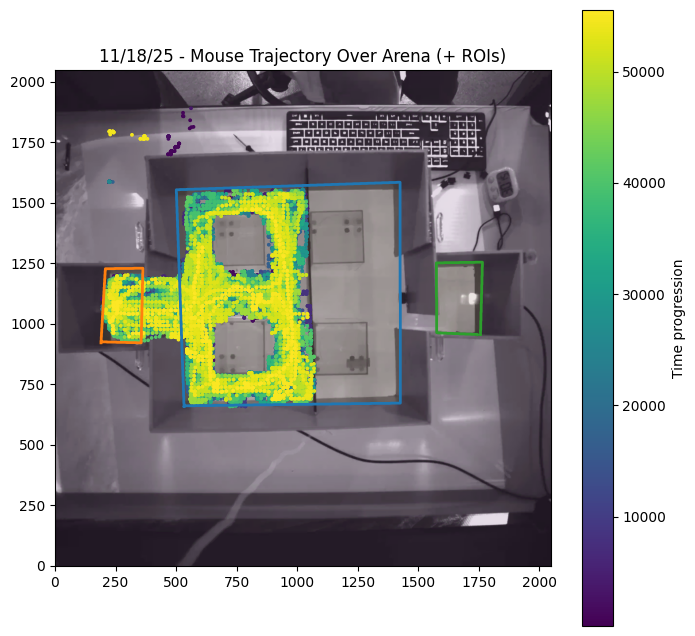

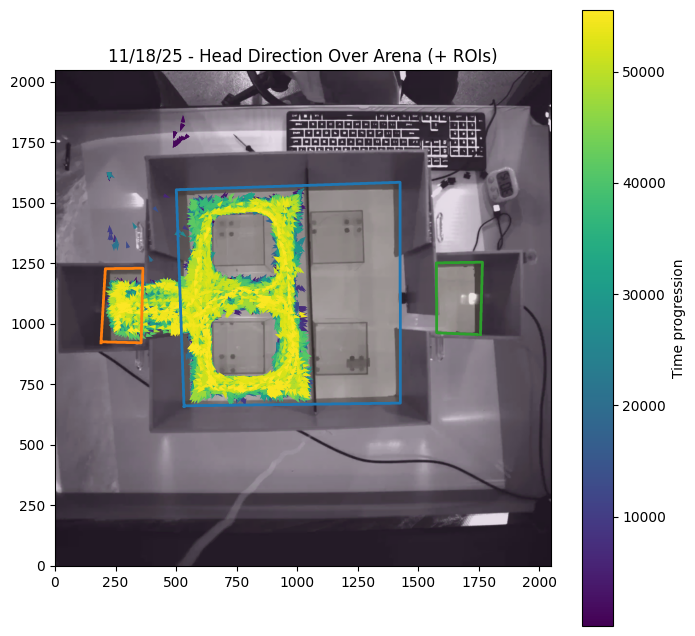

In [35]:
plot_trajectory_over_arena(aligned_sessions_with_rois["11/18/25"], video_path=sessions.loc[sessions["session_id"] == "11/18/25", "beh_vid"].iloc[0], masks=masks_by_session["11/18/25"], x_col="nose.x", y_col="nose.y")
plot_head_direction_over_arena(aligned_sessions_with_rois["11/18/25"], video_path=sessions.loc[sessions["session_id"] == "11/18/25", "beh_vid"].iloc[0], masks=masks_by_session["11/18/25"], x_col="ear_mid_x", y_col="ear_mid_y")

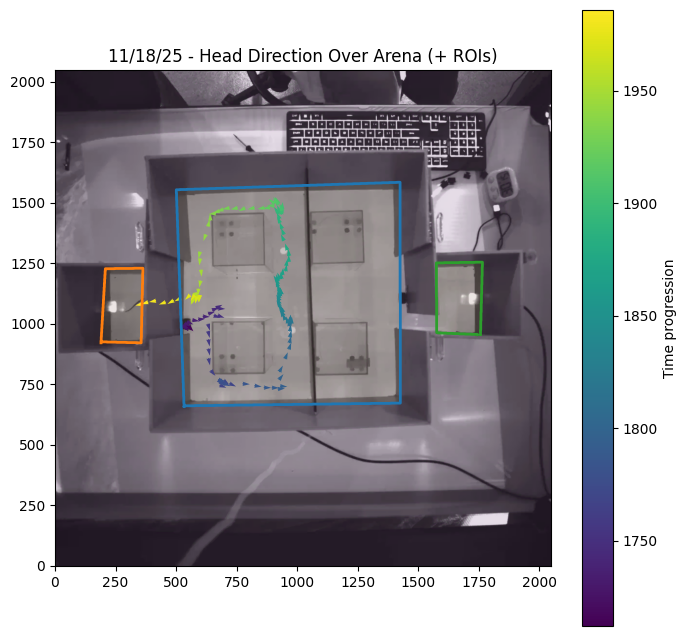

In [36]:
t0 = trials_by_session["11/18/25"][0]          # (start_i, end_i)
s, e = t0

df_trial = aligned_sessions_with_rois["11/18/25"].iloc[s:e+1].copy()   # +1 to include end frame

plot_head_direction_over_arena(
    df_trial,
    video_path=sessions.loc[sessions["session_id"] == "11/18/25", "beh_vid"].iloc[0],
    masks=masks_by_session["11/18/25"],
    x_col="ear_mid_x",
    y_col="ear_mid_y",
    cmap="viridis")

In [ ]:
import ipywidgets as widgets
from IPython.display import display, clear_output

session_ids = sorted(trials_by_session.keys())

session_dropdown = widgets.Dropdown(
    options=session_ids,
    value=session_ids[0],
    description="Session:"
)

trial_slider = widgets.IntSlider(
    value=0,
    min=0,
    max=len(trials_by_session[session_dropdown.value]) - 1,
    step=1,
    description="Trial",
    continuous_update=False
)

def update_slider_range(change):
    session = change["new"]
    trial_slider.max = len(trials_by_session[session]) - 1
    trial_slider.value = 0

session_dropdown.observe(update_slider_range, names="value")

def show_trial(trial_idx, session):
    clear_output(wait=True)

    trials = trials_by_session[session]
    s, e = map(int, trials[trial_idx])

    df_trial = aligned_sessions_with_rois[session].iloc[s:e+1].copy()

    video_path = sessions.loc[
        sessions["session_id"] == session,
        "beh_vid"
    ].iloc[0]

    plot_head_direction_over_arena(
        df_trial,
        video_path=str(video_path),
        masks=masks_by_session[session],
        x_col="ear_mid_x",
        y_col="ear_mid_y",
        title=f"{session} - Trial {trial_idx} Head Direction Over Arena"
    )

out = widgets.interactive_output(
    show_trial,
    {
        "trial_idx": trial_slider,
        "session": session_dropdown,
    }
)

display(session_dropdown, trial_slider, out)   

Dropdown(description='Session:', options=('11/13/25', '11/14/25', '11/18/25', '11/20/25', '11/21/25', '11/25/2…

IntSlider(value=0, continuous_update=False, description='Trial', max=89)

Output()

In [38]:
aligned_sessions_with_rois["11/18/25"]

,global_idx,global_ts,Value,beh_ts,recorded_idx,beh_frame_idx,beh_dropped,neu_ts,neu_dropped,nose.x,...,in_startbox_L,startbox_L_signed_dist_px,startbox_L_dist_px,in_startbox_R,startbox_R_signed_dist_px,startbox_R_dist_px,arena_center_x,arena_center_y,dist_to_arena_center_px,dist_to_arena_center_norm
0,0,2025-11-18 21:28:59.174028800+00:00,0.0,2025-11-18 21:28:59.174028800+00:00,0.0,0.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
1,1,2025-11-18 21:28:59.207362133+00:00,1.0,2025-11-18 21:28:59.205824+00:00,1.0,1.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
2,2,2025-11-18 21:28:59.240695466+00:00,2.0,2025-11-18 21:28:59.239552+00:00,2.0,2.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
3,3,2025-11-18 21:28:59.274028799+00:00,3.0,2025-11-18 21:28:59.272422400+00:00,3.0,3.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
4,4,2025-11-18 21:28:59.307362132+00:00,4.0,2025-11-18 21:28:59.306009600+00:00,4.0,4.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55659,55659,2025-11-18 21:59:54.474010247+00:00,55651.0,2025-11-18 21:59:54.470592+00:00,55651.0,55651.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55660,55660,2025-11-18 21:59:54.507343580+00:00,55652.0,2025-11-18 21:59:54.503616+00:00,55652.0,55652.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55661,55661,2025-11-18 21:59:54.540676913+00:00,55653.0,2025-11-18 21:59:54.537305600+00:00,55653.0,55653.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55662,55662,2025-11-18 21:59:54.574010246+00:00,55654.0,2025-11-18 21:59:54.570227200+00:00,55654.0,55654.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN


## Trial Stats

In [39]:
import numpy as np
import pandas as pd

def compute_trial_metrics(
    df: pd.DataFrame,
    trials: list[tuple[int, int]],
    fps: float,
    x_col: str = "ear_mid_x",
    y_col: str = "ear_mid_y",
    arena_col: str = "in_arena",
    start_col: str = "in_startbox_L",
    boundary_dist_col: str = "arena_signed_dist_px",
    boundary_thresh_px: float = 20.0,
    pause_speed_thresh_px_s: float = 5.0,
    turn_burst_thresh_deg_s: float = 120.0,
):
    dt = 1.0 / fps
    trial_rows = []

    for trial_idx, (s, e) in enumerate(trials):
        s, e = int(s), int(e)
        trial_df = df.iloc[s:e+1].copy()

        duration_s = len(trial_df) * dt

        x_all = pd.to_numeric(trial_df[x_col], errors="coerce").to_numpy(dtype=float)
        y_all = pd.to_numeric(trial_df[y_col], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(x_all) & np.isfinite(y_all)
        pos_valid_fraction = float(np.mean(valid)) if len(valid) else np.nan

        x = x_all[valid]
        y = y_all[valid]
        if len(x) < 2:
            continue

        dx = np.diff(x)
        dy = np.diff(y)
        step_dist = np.sqrt(dx**2 + dy**2)
        path_len = float(np.nansum(step_dist))

        straight_dist = float(np.hypot(x[-1] - x[0], y[-1] - y[0]))
        efficiency = straight_dist / path_len if path_len > 0 else np.nan

        speed = step_dist * fps
        mean_speed = float(np.nanmean(speed)) if len(speed) else np.nan
        max_speed = float(np.nanmax(speed)) if len(speed) else np.nan

        speed_valid = speed[np.isfinite(speed)]
        pause_fraction = float(np.mean(speed_valid < pause_speed_thresh_px_s)) if len(speed_valid) else np.nan

        arena_time = float(trial_df[arena_col].mean()) if arena_col in trial_df else np.nan
        start_time = float(trial_df[start_col].mean()) if start_col in trial_df else np.nan

        # boundary proximity: use abs(signed distance)
        boundary_pct = np.nan
        if boundary_dist_col and boundary_dist_col in trial_df.columns:
            sd = pd.to_numeric(trial_df[boundary_dist_col], errors="coerce").to_numpy(dtype=float)
            boundary_pct = float(np.nanmean(np.abs(sd) <= boundary_thresh_px))

        # center distance (normalized)
        mean_center_dist = np.nan
        median_center_dist = np.nan
        center_fraction = np.nan
        if "dist_to_arena_center_norm" in trial_df.columns:
            cd = pd.to_numeric(trial_df["dist_to_arena_center_norm"], errors="coerce").to_numpy(dtype=float)
            mean_center_dist = float(np.nanmean(cd))
            median_center_dist = float(np.nanmedian(cd))
            center_fraction = float(np.nanmean(cd <= 0.5))  # inner half-radius

        # arena entry latency within trial
        arena_entry_latency_s = np.nan
        if arena_col in trial_df.columns:
            a = trial_df[arena_col].to_numpy(dtype=bool)
            if a.any():
                arena_entry_latency_s = float(np.argmax(a) / fps)

        # turning metrics (if present)
        mean_ang_speed = np.nan
        p95_ang_speed = np.nan
        turn_burst_fraction = np.nan
        if "ang_vel_speed" in trial_df.columns:
            ang = pd.to_numeric(trial_df["ang_vel_speed"], errors="coerce").to_numpy(dtype=float)
            ang = ang[np.isfinite(ang)]
            if len(ang):
                mean_ang_speed = float(np.mean(ang))
                p95_ang_speed = float(np.percentile(ang, 95))
                turn_burst_fraction = float(np.mean(ang >= turn_burst_thresh_deg_s))

        trial_rows.append({
            "trial": trial_idx,
            "start_idx": s,
            "end_idx": e,
            "n_frames": int(len(trial_df)),
            "duration_s": float(duration_s),
            "pos_valid_fraction": pos_valid_fraction,
            "path_len_px": path_len,
            "straight_px": straight_dist,
            "efficiency": efficiency,
            "mean_speed_px_s": mean_speed,
            "max_speed_px_s": max_speed,
            "pause_fraction": pause_fraction,
            "arena_fraction": arena_time,
            "startbox_fraction": start_time,
            "arena_entry_latency_s": arena_entry_latency_s,
            "boundary_fraction": boundary_pct,
            "mean_center_dist_norm": mean_center_dist,
            "median_center_dist_norm": median_center_dist,
            "center_fraction": center_fraction,
            "mean_ang_speed_deg_s": mean_ang_speed,
            "p95_ang_speed_deg_s": p95_ang_speed,
            "turn_burst_fraction": turn_burst_fraction,
        })

    return pd.DataFrame(trial_rows)

In [40]:
aligned_sessions_with_rois["11/18/25"]

,global_idx,global_ts,Value,beh_ts,recorded_idx,beh_frame_idx,beh_dropped,neu_ts,neu_dropped,nose.x,...,in_startbox_L,startbox_L_signed_dist_px,startbox_L_dist_px,in_startbox_R,startbox_R_signed_dist_px,startbox_R_dist_px,arena_center_x,arena_center_y,dist_to_arena_center_px,dist_to_arena_center_norm
0,0,2025-11-18 21:28:59.174028800+00:00,0.0,2025-11-18 21:28:59.174028800+00:00,0.0,0.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
1,1,2025-11-18 21:28:59.207362133+00:00,1.0,2025-11-18 21:28:59.205824+00:00,1.0,1.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
2,2,2025-11-18 21:28:59.240695466+00:00,2.0,2025-11-18 21:28:59.239552+00:00,2.0,2.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
3,3,2025-11-18 21:28:59.274028799+00:00,3.0,2025-11-18 21:28:59.272422400+00:00,3.0,3.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
4,4,2025-11-18 21:28:59.307362132+00:00,4.0,2025-11-18 21:28:59.306009600+00:00,4.0,4.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55659,55659,2025-11-18 21:59:54.474010247+00:00,55651.0,2025-11-18 21:59:54.470592+00:00,55651.0,55651.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55660,55660,2025-11-18 21:59:54.507343580+00:00,55652.0,2025-11-18 21:59:54.503616+00:00,55652.0,55652.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55661,55661,2025-11-18 21:59:54.540676913+00:00,55653.0,2025-11-18 21:59:54.537305600+00:00,55653.0,55653.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN
55662,55662,2025-11-18 21:59:54.574010246+00:00,55654.0,2025-11-18 21:59:54.570227200+00:00,55654.0,55654.0,False,NaT,True,NaN,...,False,NaN,NaN,False,NaN,NaN,884.4,1025.8,NaN,NaN


In [41]:
all_trial_summaries = []

for session_id, aligned_df in aligned_sessions_with_rois.items():
    trials = trials_by_session.get(session_id, [])
    if not trials:
        continue

    trial_summary = compute_trial_metrics(
        aligned_df,
        trials,
        fps=30.0,
        x_col="ear_mid_x",
        y_col="ear_mid_y",
        arena_col="in_arena",
        start_col="in_startbox_L",
    )
    trial_summary["session_id"] = session_id
    all_trial_summaries.append(trial_summary)

trial_df = pd.concat(all_trial_summaries, ignore_index=True)

In [42]:
trial_df

,trial,start_idx,end_idx,n_frames,duration_s,pos_valid_fraction,path_len_px,straight_px,efficiency,mean_speed_px_s,...,startbox_fraction,arena_entry_latency_s,boundary_fraction,mean_center_dist_norm,median_center_dist_norm,center_fraction,mean_ang_speed_deg_s,p95_ang_speed_deg_s,turn_burst_fraction,session_id
0,0,1630,1996,367,12.233333,0.980926,3224.921691,159.160318,0.049353,269.492063,...,0.002725,0.0,0.016349,0.441507,0.420615,0.667575,2.909072,8.891103,0.0,11/6/25
1,1,2192,2356,165,5.500000,1.000000,1768.130201,164.104290,0.092812,323.438451,...,0.006061,0.0,0.018182,0.345262,0.384572,0.951515,3.239554,8.356731,0.0,11/6/25
2,2,2653,2947,295,9.833333,0.993220,2767.680557,178.850610,0.064621,284.350742,...,0.003390,0.0,0.016949,0.421972,0.401310,0.650847,2.947896,9.103046,0.0,11/6/25
3,3,3060,3176,117,3.900000,0.991453,1650.271327,163.018856,0.098783,430.505563,...,0.008547,0.0,0.025641,0.453684,0.464561,0.564103,3.336324,8.058901,0.0,11/6/25
4,4,3424,3644,221,7.366667,0.850679,1909.366964,168.284616,0.088136,306.315556,...,0.004525,0.0,0.013575,0.381406,0.399820,0.588235,2.967732,8.214366,0.0,11/6/25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
614,40,47904,48150,247,8.233333,1.000000,2369.678094,177.092327,0.074733,288.985133,...,0.004049,0.0,0.012146,0.366216,0.360736,0.809717,2.846022,8.908471,0.0,11/25/25
615,41,50535,50928,394,13.133333,1.000000,3111.213849,153.612159,0.049374,237.497240,...,0.002538,0.0,0.106599,0.354950,0.350491,0.852792,2.809966,8.151411,0.0,11/25/25
616,42,51489,52959,1471,49.033333,0.997281,7549.085446,177.509949,0.023514,154.483331,...,0.000680,0.0,0.031951,0.423662,0.424997,0.829368,2.227136,7.955015,0.0,11/25/25
617,43,53097,54401,1305,43.500000,0.850575,7513.442034,207.968041,0.027679,203.249108,...,0.000766,0.0,0.022989,0.436961,0.418261,0.518774,2.048826,7.821773,0.0,11/25/25


In [43]:
trial_df = trial_df.copy()
trial_df["session_date"] = pd.to_datetime(trial_df["session_id"], errors="coerce").dt.date
trial_df = trial_df.sort_values(["session_date", "trial"]).reset_index(drop=True)

/var/folders/k4/zr04khhn74zcj29mf4f0v8hc0000gn/T/ipykernel_51584/1132317504.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  trial_df["session_date"] = pd.to_datetime(trial_df["session_id"], errors="coerce").dt.date


In [44]:
trial_df_clean = trial_df.query(
    "duration_s >= 0.5 and pos_valid_fraction >= 0.8"
).copy()

In [45]:
import numpy as np
import pandas as pd

def iqr(x):
    x = pd.to_numeric(x, errors="coerce").dropna()
    if len(x) == 0:
        return np.nan
    return float(np.percentile(x, 75) - np.percentile(x, 25))

day_summary = (
    trial_df_clean
    .groupby("session_date")
    .agg(
        # volume
        n_trials=("trial", "count"),

        # duration
        mean_duration_s=("duration_s", "mean"),
        median_duration_s=("duration_s", "median"),
        iqr_duration_s=("duration_s", iqr),

        # performance / strategy
        mean_efficiency=("efficiency", "mean"),
        median_efficiency=("efficiency", "median"),
        mean_entry_latency_s=("arena_entry_latency_s", "mean"),
        median_entry_latency_s=("arena_entry_latency_s", "median"),

        # movement
        mean_speed_px_s=("mean_speed_px_s", "mean"),
        median_speed_px_s=("mean_speed_px_s", "median"),
        mean_path_len_px=("path_len_px", "mean"),
        median_path_len_px=("path_len_px", "median"),
        mean_pause_frac=("pause_fraction", "mean"),

        # spatial bias
        mean_boundary_frac=("boundary_fraction", "mean"),
        mean_center_dist_norm=("mean_center_dist_norm", "mean"),
        mean_center_frac=("center_fraction", "mean"),

        # turning (if present)
        mean_turn_deg_s=("mean_ang_speed_deg_s", "mean"),
        mean_turn_p95_deg_s=("p95_ang_speed_deg_s", "mean"),
        mean_turn_burst_frac=("turn_burst_fraction", "mean"),

        # tracking quality
        mean_pos_valid_frac=("pos_valid_fraction", "mean"),
        median_pos_valid_frac=("pos_valid_fraction", "median"),
    )
    .reset_index()
)

day_summary

,session_date,n_trials,mean_duration_s,median_duration_s,iqr_duration_s,mean_efficiency,median_efficiency,mean_entry_latency_s,median_entry_latency_s,mean_speed_px_s,...,median_path_len_px,mean_pause_frac,mean_boundary_frac,mean_center_dist_norm,mean_center_frac,mean_turn_deg_s,mean_turn_p95_deg_s,mean_turn_burst_frac,mean_pos_valid_frac,median_pos_valid_frac
0,2025-11-06,125,11.154133,8.600000,9.633333,0.104852,0.076167,0.0,0.0,270.828159,...,2253.920644,0.014086,0.060934,0.423434,0.707614,3.456102,10.439077,0.0,0.987111,1.000000
1,2025-11-13,89,12.387640,9.933333,8.700000,0.077025,0.051086,0.0,0.0,500.407585,...,3002.813317,0.039573,0.084005,0.463621,0.671399,4.001258,14.211834,0.0,0.980659,0.994832
2,2025-11-14,75,10.549333,8.766667,6.966667,0.101437,0.069002,0.0,0.0,273.651312,...,2551.474902,0.018685,0.054488,0.432249,0.666214,3.279978,8.720531,0.0,0.989772,1.000000
3,2025-11-18,82,13.839431,11.333333,11.450000,0.055784,0.051679,0.0,0.0,352.639637,...,3513.657827,0.019132,0.028000,0.395066,0.729694,3.636857,10.313559,0.0,0.977479,0.987786
4,2025-11-20,86,11.992636,9.133333,8.708333,0.092126,0.074735,0.0,0.0,277.565022,...,2552.258823,0.019570,0.050499,0.416828,0.720599,3.471933,8.981906,0.0,0.979251,0.991516
5,2025-11-21,114,11.750000,9.733333,8.041667,0.087878,0.067149,0.0,0.0,273.051056,...,2536.790376,0.033097,0.060128,0.416476,0.724810,3.501399,9.493069,0.0,0.980882,0.990498
6,2025-11-25,44,25.888636,15.100000,20.433333,0.053475,0.053050,0.0,0.0,240.282853,...,3103.369861,0.034734,0.025741,0.391104,0.734848,2.841442,8.567213,0.0,0.981513,1.000000


In [46]:
import matplotlib.pyplot as plt
import numpy as np

def plot_metric_with_error(
    df,
    x_col,
    y_col,
    err_col=None,
    ylabel="",
    title="",
    color="#006A67",
):
    df = df.sort_values(x_col)

    x = df[x_col]
    y = df[y_col]

    plt.figure()
    plt.plot(x, y, marker="*", markersize=8, color=color)

    if err_col and err_col in df.columns:
        err = df[err_col]
        plt.fill_between(x, y - err/2, y + err/2, alpha=0.2, color=color)

    plt.xticks(x, rotation=45)
    plt.ylabel(ylabel)
    plt.title(title)
    plt.tight_layout()
    plt.show()

In [47]:
rewards = [23,9,21,82,17,16,6]
num_trials = day_summary["n_trials"].to_numpy()

reward_percentage = rewards[:len(num_trials)] / num_trials

print(reward_percentage)

[0.184      0.1011236  0.28       1.         0.19767442 0.14035088
 0.13636364]


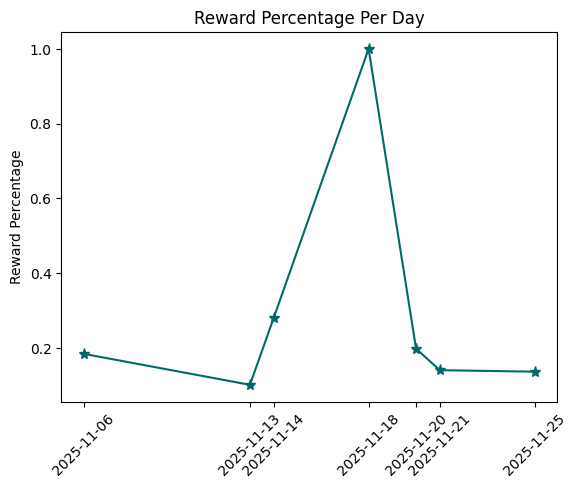

In [48]:
plt.figure()
plt.plot(day_summary["session_date"], reward_percentage, color="#006A67", marker="*", markersize=8)
plt.xticks(day_summary["session_date"], rotation=45)
plt.ylabel("Reward Percentage")
plt.title("Reward Percentage Per Day")
plt.show()

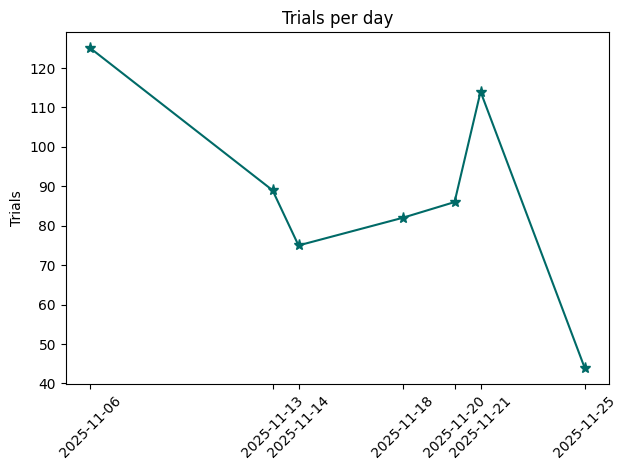

In [49]:
#trials per day
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="n_trials",
    ylabel="Trials",
    title="Trials per day",
)

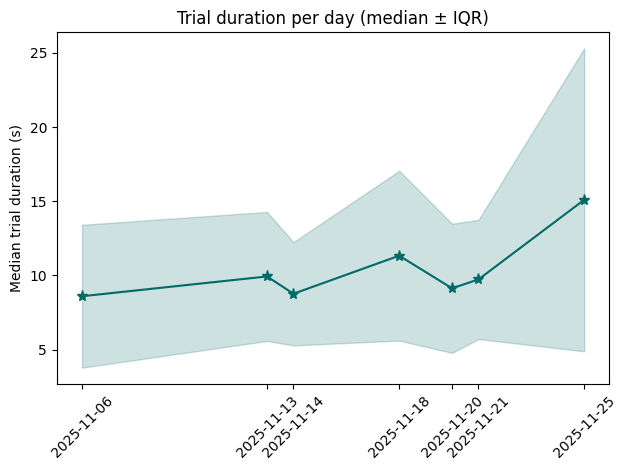

In [50]:
#trial duration
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="median_duration_s",
    err_col="iqr_duration_s",
    ylabel="Median trial duration (s)",
    title="Trial duration per day (median ± IQR)",
)

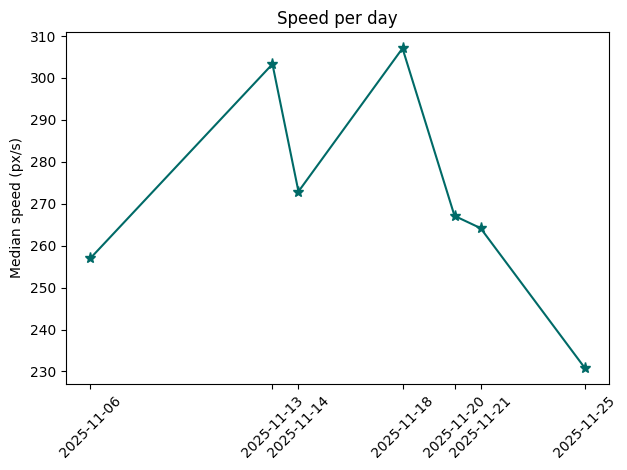

In [51]:
#speed
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="median_speed_px_s",
    ylabel="Median speed (px/s)",
    title="Speed per day",
)

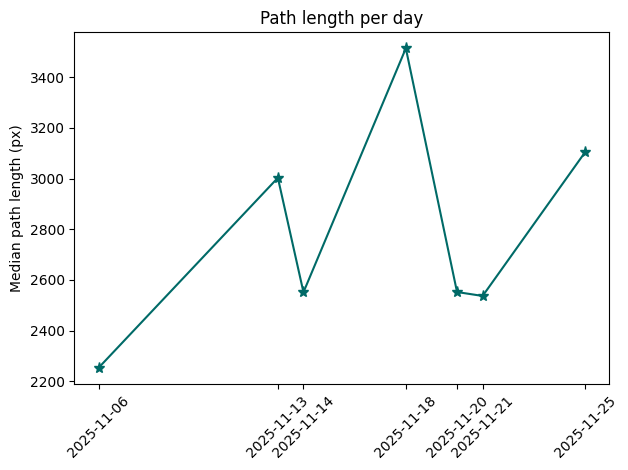

In [52]:
#path length
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="median_path_len_px",
    ylabel="Median path length (px)",
    title="Path length per day",
)

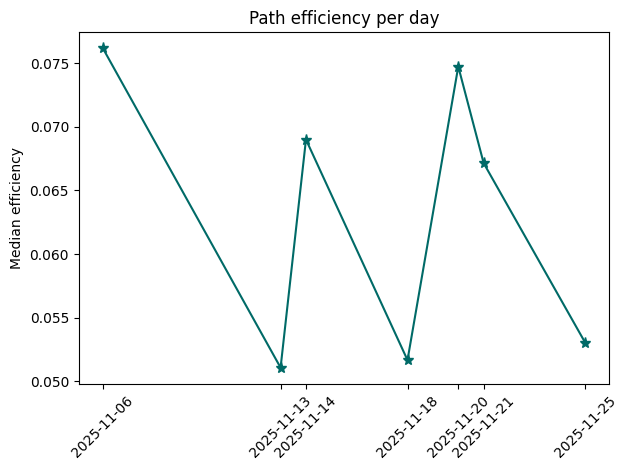

In [53]:
#efficiency
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="median_efficiency",
    ylabel="Median efficiency",
    title="Path efficiency per day",
)

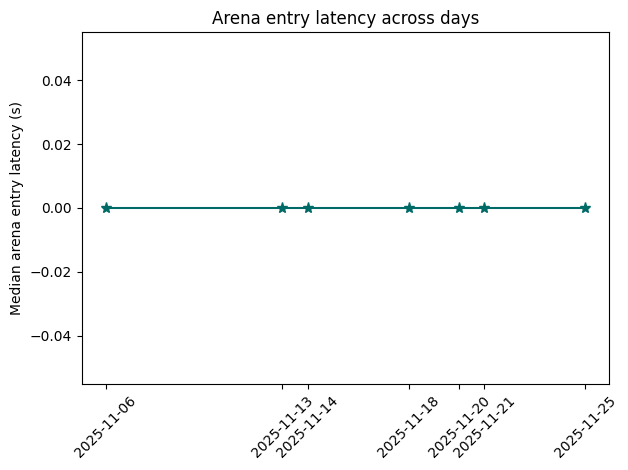

In [54]:
#arena entry latency
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="median_entry_latency_s",
    ylabel="Median arena entry latency (s)",
    title="Arena entry latency across days",
)

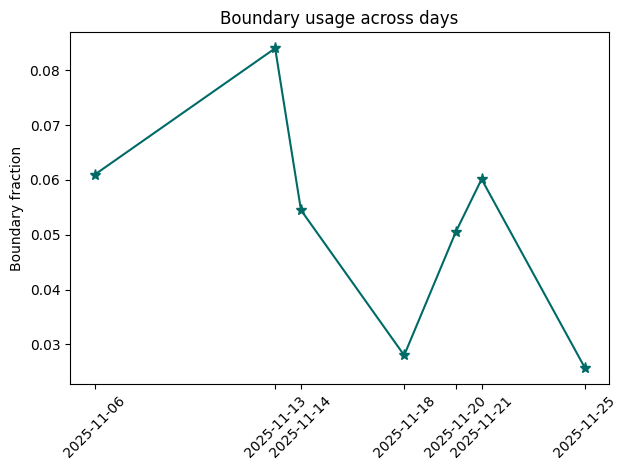

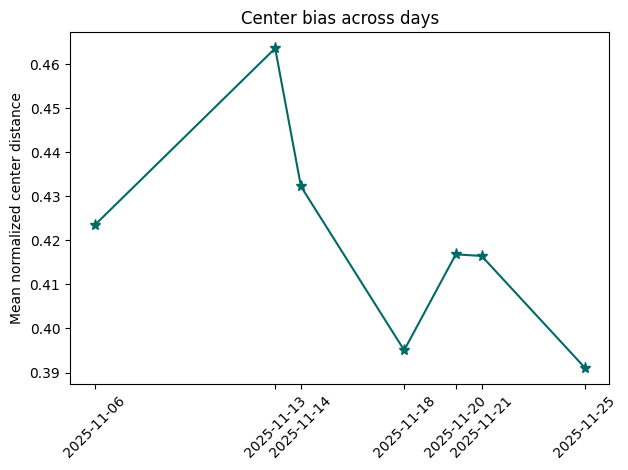

In [55]:
#boundary vs center bias

plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="mean_boundary_frac",
    ylabel="Boundary fraction",
    title="Boundary usage across days",
)

plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="mean_center_dist_norm",
    ylabel="Mean normalized center distance",
    title="Center bias across days",
)

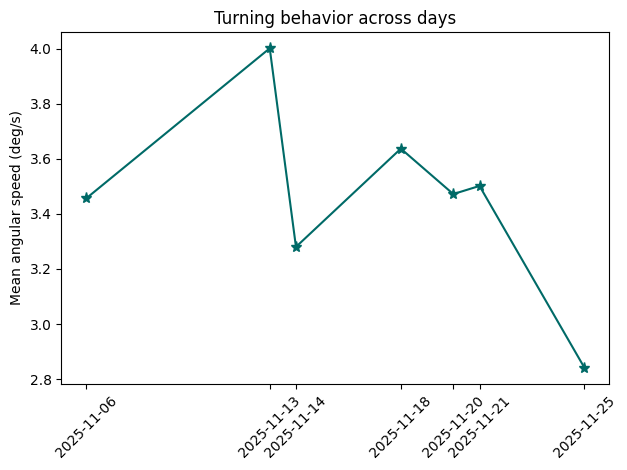

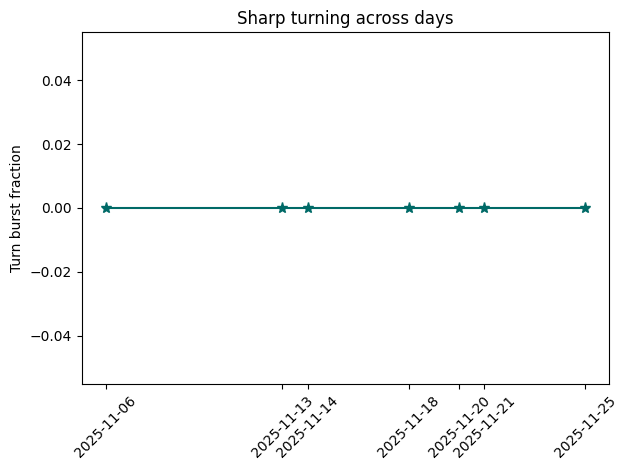

In [56]:
#turning behavior
plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="mean_turn_deg_s",
    ylabel="Mean angular speed (deg/s)",
    title="Turning behavior across days",
)

plot_metric_with_error(
    day_summary,
    x_col="session_date",
    y_col="mean_turn_burst_frac",
    ylabel="Turn burst fraction",
    title="Sharp turning across days",
)

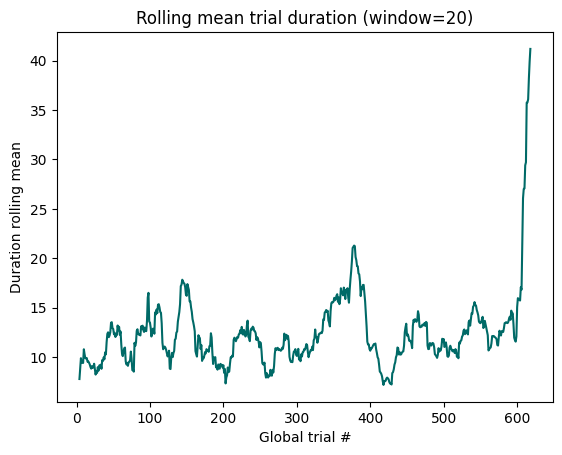

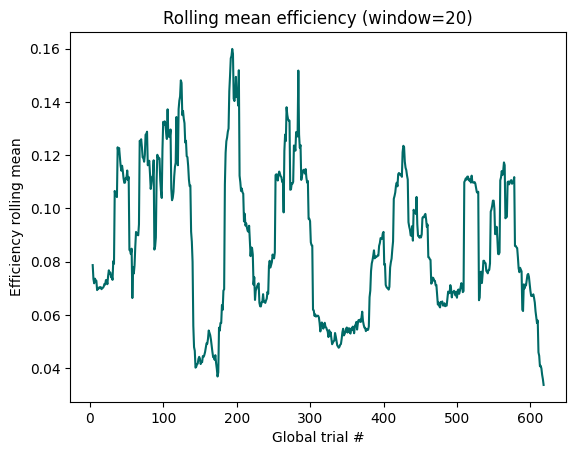

In [57]:
trial_df["trial_global"] = np.arange(len(trial_df))
trial_df["dur_roll"] = trial_df["duration_s"].rolling(20, min_periods=5).mean()
trial_df["eff_roll"] = trial_df["efficiency"].rolling(20, min_periods=5).mean()

plt.figure()
plt.plot(trial_df["trial_global"], trial_df["dur_roll"], color="#006A67")
plt.xlabel("Global trial #")
plt.ylabel("Duration rolling mean")
plt.title("Rolling mean trial duration (window=20)")
plt.show()

plt.figure()
plt.plot(trial_df["trial_global"], trial_df["eff_roll"], color="#006A67")
plt.xlabel("Global trial #")
plt.ylabel("Efficiency rolling mean")
plt.title("Rolling mean efficiency (window=20)")
plt.show()

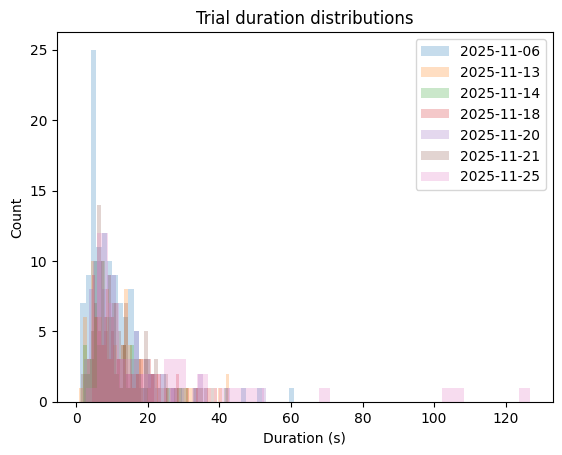

In [58]:
plt.figure()
for d, g in trial_df.groupby("session_date"):
    plt.hist(g["duration_s"].dropna(), bins=40, alpha=0.25, label=str(d))
plt.xlabel("Duration (s)")
plt.ylabel("Count")
plt.legend()
plt.title("Trial duration distributions")
plt.show()